## Cell 1: Libraries & Data Loading

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("supermarket_sales - Sheet1.csv")

print("--- DATA QUALITY CHECK ---")
print("Shape: ", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nData Types:\n", df.dtypes)

--- DATA QUALITY CHECK ---
Shape:  (1000, 17)

Missing Values:
 Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Total                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

Data Types:
 Invoice ID                  object
Branch                      object
City                        object
Customer type               object
Gender                      object
Product line                object
Unit price                 float64
Quantity                     int64
Tax 5%                     float64
Total                      float64
Date                        object
Time                        obj

## Cell 2: Data Cleaning & Date/Time Formatting

In [ ]:

df['Date'] = pd.to_datetime(df['Date'])
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M').dt.time
df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M:%S').dt.hour

df['Gross Margin %'] = (df['gross income'] / df['Total']) * 100

print("Dtypes formatted successfully.")
df.head(3)

Dtypes formatted successfully.


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating,Hour,Gross Margin %
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,13:08:00,Ewallet,522.83,4.761905,26.1415,9.1,13,4.761905
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,10:29:00,Cash,76.40,4.761905,3.8200,9.6,10,4.761905
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,13:23:00,Credit card,324.31,4.761905,16.2155,7.4,13,4.761905


## Cell 3: Groupby Aggregations & Analysis

In [12]:
print("--- TOTAL SALES & ORDERS BY BRANCH ---")
print(df.groupby('Branch')['Total'].agg(['sum', 'count', 'mean']))

print("\n--- TOTAL SALES BY PRODUCT LINE ---")
print(df.groupby('Product line')['Total'].agg(['sum', 'count']).sort_values(by='sum', ascending=False))

print("\n--- TOTAL SALES BY CUSTOMER TYPE ---")
print(df.groupby('Customer type')['Total'].agg(['sum', 'count']))

print("\n--- TOTAL SALES BY GENDER ---")
print(df.groupby('Gender')['Total'].agg(['sum', 'count']))

print("\n--- BUSIEST HOURS ---")
print(df.groupby('Hour')['Total'].agg(['count', 'sum']).sort_values(by='count', ascending=False))

--- TOTAL SALES & ORDERS BY BRANCH ---
                sum  count        mean
Branch                                
A       106200.3705    340  312.354031
B       106197.6720    332  319.872506
C       110568.7065    328  337.099715

--- TOTAL SALES BY PRODUCT LINE ---
                               sum  count
Product line                             
Food and beverages      56144.8440    174
Sports and travel       55122.8265    166
Electronic accessories  54337.5315    170
Fashion accessories     54305.8950    178
Home and lifestyle      53861.9130    160
Health and beauty       49193.7390    152

--- TOTAL SALES BY CUSTOMER TYPE ---
                      sum  count
Customer type                   
Member         164223.444    501
Normal         158743.305    499

--- TOTAL SALES BY GENDER ---
               sum  count
Gender                   
Female  167882.925    501
Male    155083.824    499

--- BUSIEST HOURS ---
      count         sum
Hour                   
19      113  3969

## Cell 4: Visualizations & Heatmap (3 Required + 1 Bonus)

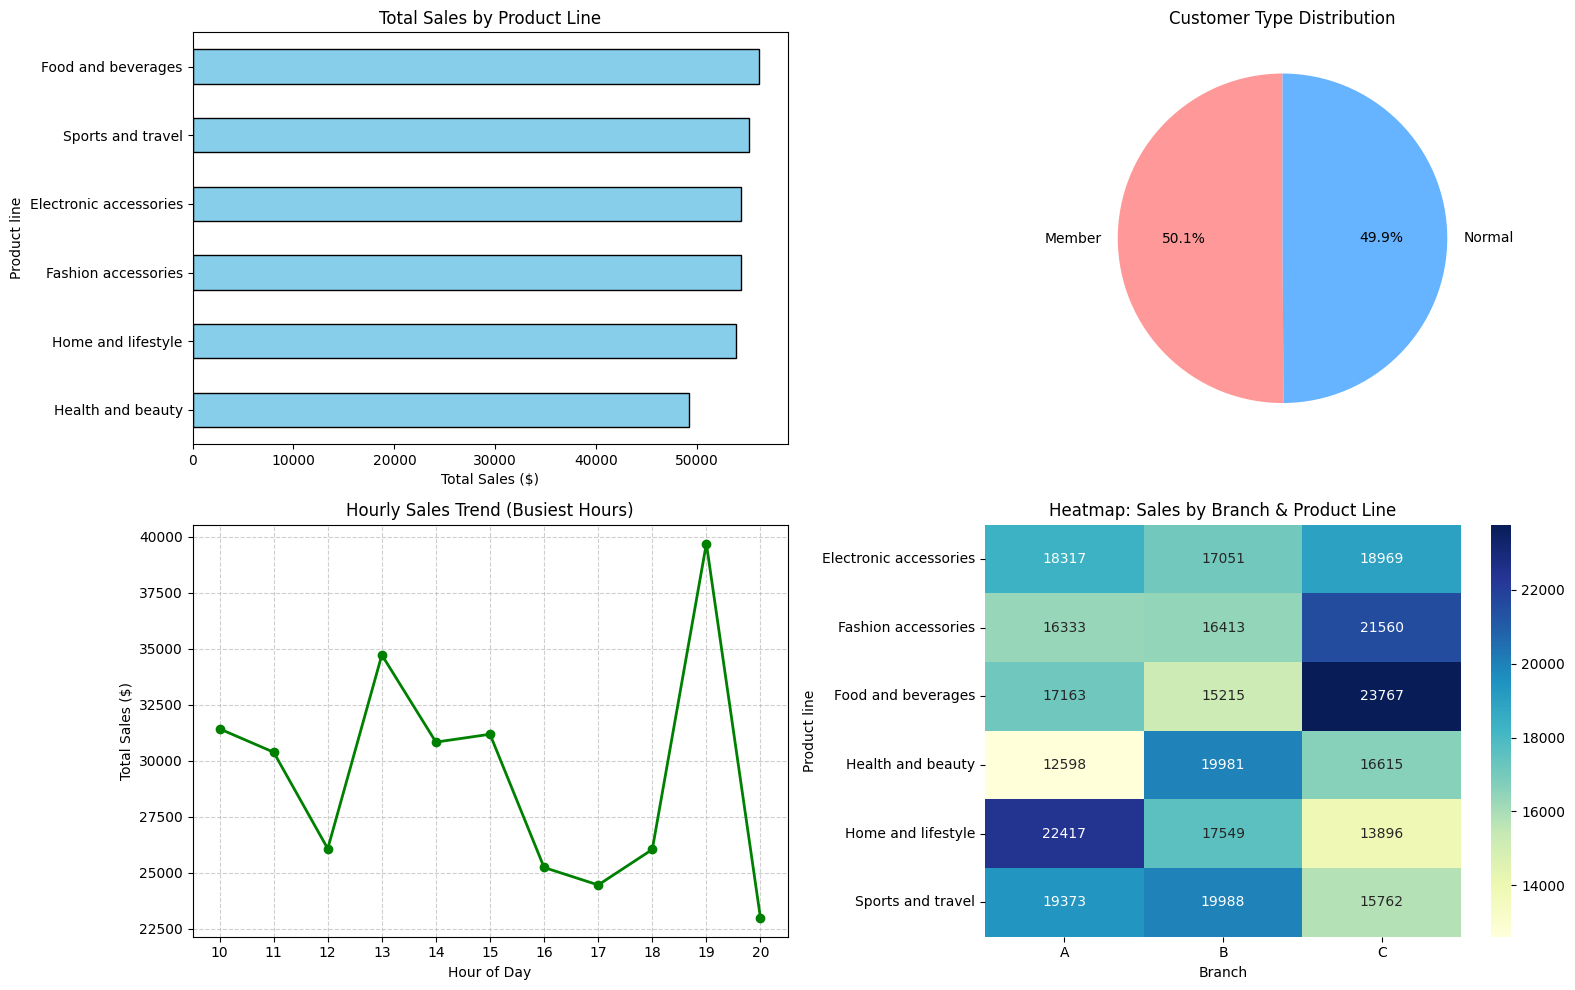

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Bar Chart: Sales by Product Line
product_sales = df.groupby('Product line')['Total'].sum().sort_values(ascending=True)
product_sales.plot(kind='barh', ax=axes[0, 0], color='skyblue', edgecolor='black')
axes[0, 0].set_title('Total Sales by Product Line')
axes[0, 0].set_xlabel('Total Sales ($)')

# 2. Pie Chart: Customer Type Share
customer_counts = df['Customer type'].value_counts()
axes[0, 1].pie(customer_counts, labels=customer_counts.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], startangle=90)
axes[0, 1].set_title('Customer Type Distribution')

# 3. Line Chart: Hourly Sales Trend
hourly_sales = df.groupby('Hour')['Total'].sum()
axes[1, 0].plot(hourly_sales.index, hourly_sales.values, marker='o', color='green', linewidth=2)
axes[1, 0].set_title('Hourly Sales Trend (Busiest Hours)')
axes[1, 0].set_xlabel('Hour of Day')
axes[1, 0].set_ylabel('Total Sales ($)')
axes[1, 0].set_xticks(hourly_sales.index)
axes[1, 0].grid(True, linestyle='--', alpha=0.6)

# 4. Bonus: Heatmap of Sales by Branch and Product Line
branch_product = df.pivot_table(index='Product line', columns='Branch', values='Total', aggfunc='sum')
sns.heatmap(branch_product, annot=True, fmt=".0f", cmap="YlGnBu", ax=axes[1, 1])
axes[1, 1].set_title('Heatmap: Sales by Branch & Product Line')

plt.tight_layout()
plt.show()